<a href="https://colab.research.google.com/github/madebyann/colab/blob/main/polinomi_di_taylor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Definizione (Polinomio di Taylor)
Sia $f: I \subseteq \mathbb{R} \to \mathbb{R}$ una funzione e sia $x_0$ un punto interno ad $I$. Si dice che un polinomio della forma:
$$P_n(x) = a_0 + a_1(x - x_0) + a_2(x - x_0)^2 + \dots + a_n(x - x_0)^n = \sum_{k=0}^{n} a_k (x - x_0)^k$$
è un **polinomio di Taylor di $f$ centrato in $x_0$ di grado $n$**.

---

### 2. Teorema (Polinomio di Taylor con resto di Peano)
Sia $f: I \subseteq \mathbb{R} \to \mathbb{R}$, sia $f$ derivabile $n-1$ volte in $I$ e sia $x_0$ interno ad $I$. Se esiste la derivata $n$-esima $f^{(n)}(x_0)$, allora risulta:
$$f(x) = \sum_{k=0}^{n} \frac{f^{(k)}(x_0)}{k!} (x - x_0)^k + o((x - x_0)^n)$$
dove i coefficienti del polinomio sono dati da $a_k = \frac{f^{(k)}(x_0)}{k!}$.

---

### 3. Implementazione in Python
Il codice seguente traduce la teoria in pratica: utilizza il calcolo simbolico di `SymPy` per calcolare le derivate successive e determinare i coefficienti, e sfrutta `NumPy` e `Matplotlib` per visualizzare graficamente l'approssimazione della funzione originaria tramite i polinomi di Taylor dal grado $0$ al grado $5$.

Inserisci un'espressione per la tua funzione: sin(x)
Inserisci il valore di x0: 0

Espressioni analitiche dei Polinomi di Taylor per sin(x) intorno a x0=0.0:
Ordine 0: P_0(x) = 0
Ordine 1: P_1(x) = x
Ordine 2: P_2(x) = x
Ordine 3: P_3(x) = -x**3/6 + x
Ordine 4: P_4(x) = -x**3/6 + x
Ordine 5: P_5(x) = x**5/120 - x**3/6 + x


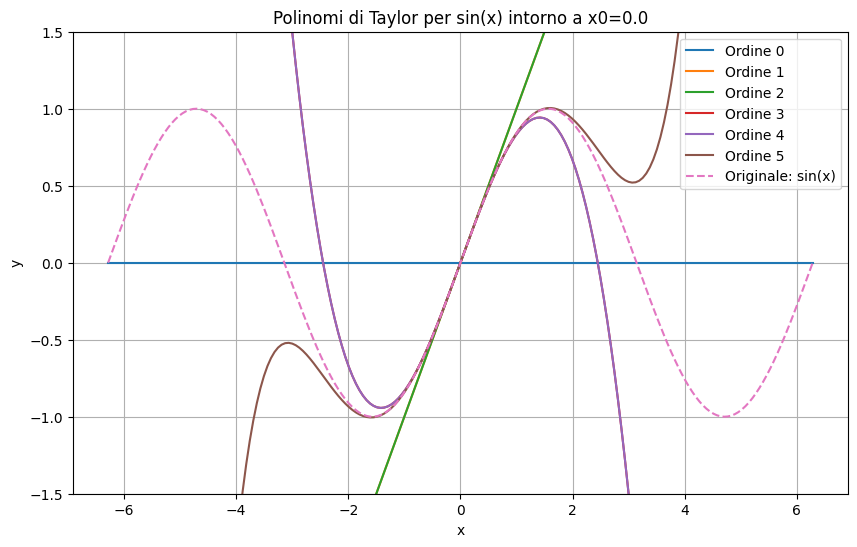

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import math

# Definisci x_sym
x_sym = sp.symbols('x')


def valore_derivata_n_esima(funzione, x_symbol_arg, x0, n_order):
    derivata = funzione
    for _ in range(n_order):
        derivata = sp.diff(derivata, x_symbol_arg)
    valore = derivata.subs(x_symbol_arg, x0)
    return valore


def pol_taylor(funzione, x_symbol_arg, x0, k_order):
    polinomio = sp.Integer(0) # Inizializza come intero SymPy
    for i in range(k_order + 1):
        derivata_n = valore_derivata_n_esima(funzione, x_symbol_arg, x0, i);
        coefficiente = derivata_n / math.factorial(i)

        polinomio += coefficiente * (x_symbol_arg - x0)**i

    return polinomio


espressione = input("Inserisci un'espressione per la tua funzione: ")
funzione = sp.sympify(espressione)
x0 = float(input("Inserisci il valore di x0: "))

# Ottieni le espressioni simboliche dei polinomi di Taylor, passando il globale x_sym
pol_0_sym = pol_taylor(funzione, x_sym, x0, 0)
pol_1_sym = pol_taylor(funzione, x_sym, x0, 1)
pol_2_sym = pol_taylor(funzione, x_sym, x0, 2)
pol_3_sym = pol_taylor(funzione, x_sym, x0, 3)
pol_4_sym = pol_taylor(funzione, x_sym, x0, 4)
pol_5_sym = pol_taylor(funzione, x_sym, x0, 5)

# Stampa le espressioni analitiche dei polinomi di Taylor
print(f"\nEspressioni analitiche dei Polinomi di Taylor per {espressione} intorno a x0={x0}:")
print(f"Ordine 0: P_0(x) = {pol_0_sym}")
print(f"Ordine 1: P_1(x) = {pol_1_sym}")
print(f"Ordine 2: P_2(x) = {pol_2_sym}")
print(f"Ordine 3: P_3(x) = {pol_3_sym}")
print(f"Ordine 4: P_4(x) = {pol_4_sym}")
print(f"Ordine 5: P_5(x) = {pol_5_sym}")

# Converti le espressioni simboliche in funzioni numeriche usando sp.lambdify
pol_0_np = sp.lambdify(x_sym, pol_0_sym, 'numpy')
pol_1_np = sp.lambdify(x_sym, pol_1_sym, 'numpy')
pol_2_np = sp.lambdify(x_sym, pol_2_sym, 'numpy')
pol_3_np = sp.lambdify(x_sym, pol_3_sym, 'numpy')
pol_4_np = sp.lambdify(x_sym, pol_4_sym, 'numpy')
pol_5_np = sp.lambdify(x_sym, pol_5_sym, 'numpy')

# Crea una funzione compatibile con numpy per la funzione originale
f_original_np = sp.lambdify(x_sym, funzione, 'numpy')

xi = -2*np.pi
xf = 2*np.pi
n_points = 200

x_vals = np.linspace(xi, xf, n_points)

# Calcola i valori y per il plot utilizzando le funzioni lambdify
# Aggiungi un controllo per assicurarti che i risultati scalari da lambdify siano convertiti in array della forma corretta
ypol_0 = pol_0_np(x_vals)
if np.isscalar(ypol_0): ypol_0 = np.full_like(x_vals, ypol_0)

ypol_1 = pol_1_np(x_vals)
if np.isscalar(ypol_1): ypol_1 = np.full_like(x_vals, ypol_1)

ypol_2 = pol_2_np(x_vals)
if np.isscalar(ypol_2): ypol_2 = np.full_like(x_vals, ypol_2)

ypol_3 = pol_3_np(x_vals)
if np.isscalar(ypol_3): ypol_3 = np.full_like(x_vals, ypol_3)

ypol_4 = pol_4_np(x_vals)
if np.isscalar(ypol_4): ypol_4 = np.full_like(x_vals, ypol_4)

ypol_5 = pol_5_np(x_vals)
if np.isscalar(ypol_5): ypol_5 = np.full_like(x_vals, ypol_5)

y_original = f_original_np(x_vals)
# Applica il controllo scalare anche alla funzione originale nel caso sia una costante
if np.isscalar(y_original): y_original = np.full_like(x_vals, y_original)

plt.figure(figsize=(10, 6))
plt.title(f"Polinomi di Taylor per {espressione} intorno a x0={x0}")
plt.plot(x_vals, ypol_0, label='Ordine 0')
plt.plot(x_vals, ypol_1, label='Ordine 1')
plt.plot(x_vals, ypol_2, label='Ordine 2')
plt.plot(x_vals, ypol_3, label='Ordine 3')
plt.plot(x_vals, ypol_4, label='Ordine 4')
plt.plot(x_vals, ypol_5, label='Ordine 5')
plt.plot(x_vals, y_original, label=f'Originale: {espressione}', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-1.5, 1.5)
plt.legend()
plt.grid(True)
plt.show()